In [ ]:
import os

os.listdir()

['.config', 'sample_data']

In [ ]:
import os

os.listdir()

['.config', 'sample_data']

In [ ]:
import os

os.listdir()

['.config', 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())


Current directory:
/content

Files in current directory:
['.config', 'sample_data']


In [ ]:
os.listdir('/content')

['.config', 'sample_data']

In [ ]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current working directory:
/content

Files in current directory:
['.config', 'sample_data']


In [ ]:
import os

os.listdir('/content')

['.config', 'sample_data']

In [ ]:
import os

os.listdir('/content')

['.config', 'sample_data']

In [13]:
import os

os.listdir('/content')

['.config', 'sample_data']

In [15]:
import pandas as pd

sentiment_df = pd.read_csv('/fear_greed_index.csv')
print('Successfully loaded fear_greed_index.csv:')
display(sentiment_df.head())

Successfully loaded fear_greed_index.csv:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [14]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [17]:
# @title 📈 Crypto Trading & Sentiment Dashboard {display-mode: "form"}
import pandas as pd
import json
from IPython.display import HTML
from google.colab import output

# --- Error Reporting ---
def _report_js_error(message):
    print(f"JavaScript Error: {message}")
output.register_callback('report_js_error', _report_js_error)

# --- Data Loading ---
trades_df = pd.read_csv('/content/historical_data.csv')
sentiment_df = pd.read_csv('/content/fear_greed_index.csv')

# Data Cleaning
trades_df['date'] = pd.to_datetime(trades_df.get('date', trades_df.index))
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# KPIs
total_trades = len(trades_df)
avg_sentiment = round(sentiment_df['value'].mean(), 2)
latest_sentiment = sentiment_df['classification'].iloc[-1]

# Prepare JSON for JS
trades_json = trades_df.to_json(orient='records', date_format='iso')
sentiment_json = sentiment_df.to_json(orient='records', date_format='iso')

html_content = """
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body { font-family: sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; }
        .dashboard-container { max-width: 1200px; margin: auto; }
        .kpi-row { display: flex; gap: 20px; margin-bottom: 20px; }
        .kpi-card { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); flex: 1; text-align: center; }
        .kpi-card h3 { color: #555; margin: 0; font-size: 0.9rem; }
        .kpi-card p { font-size: 1.8rem; font-weight: bold; margin: 10px 0 0 0; color: #333; }
        .chart-row { display: flex; gap: 20px; margin-bottom: 20px; }
        .chart-container { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); flex: 1; display: flex; flex-direction: column; }
        .wide { flex: 2; }
        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 300px; }
        h2 { font-size: 1.2rem; margin-top: 0; color: #444; }
    </style>
</head>
<body>
<div class="dashboard-container">
    <div class="kpi-row">
        <div class="kpi-card"><h3>Total Trades</h3><p>TOTAL_TRADES</p></div>
        <div class="kpi-card"><h3>Avg Sentiment</h3><p>AVG_SENTIMENT</p></div>
        <div class="kpi-card"><h3>Latest Market State</h3><p>LATEST_SENTIMENT</p></div>
    </div>

    <div class="chart-row">
        <div class="chart-container wide">
            <h2>Sentiment Trend (Fear & Greed Index)</h2>
            <div class="canvas-wrapper"><canvas id="sentimentChart"></canvas></div>
        </div>
        <div class="chart-container">
            <h2>Sentiment Distribution</h2>
            <div class="canvas-wrapper"><canvas id="distChart"></canvas></div>
        </div>
    </div>
</div>

<script>
window.onerror = function(message) { google.colab.kernel.invokeFunction('report_js_error', [message], {}); };

const sentimentData = SENTIMENT_DATA;

const ctx = document.getElementById('sentimentChart').getContext('2d');
new Chart(ctx, {
    type: 'line',
    data: {
        labels: sentimentData.map(d => d.date.split('T')[0]).slice(-30),
        datasets: [{
            label: 'Index Value',
            data: sentimentData.map(d => d.value).slice(-30),
            borderColor: '#3498db',
            fill: false,
            tension: 0.1
        }]
    },
    options: { responsive: true, maintainAspectRatio: false }
});

const distCtx = document.getElementById('distChart').getContext('2d');
const counts = sentimentData.reduce((acc, curr) => {
    acc[curr.classification] = (acc[curr.classification] || 0) + 1;
    return acc;
}, {});

new Chart(distCtx, {
    type: 'doughnut',
    data: {
        labels: Object.keys(counts),
        datasets: [{
            data: Object.values(counts),
            backgroundColor: ['#e74c3c', '#f1c40f', '#2ecc71', '#9b59b6']
        }]
    },
    options: { responsive: true, maintainAspectRatio: false }
});
</script>
</body>
</html>
""".replace('TOTAL_TRADES', str(total_trades)).replace('AVG_SENTIMENT', str(avg_sentiment)).replace('LATEST_SENTIMENT', latest_sentiment).replace('SENTIMENT_DATA', sentiment_json)

display(HTML(html_content))

In [18]:
trades_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01 00:00:00.000000000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01 00:00:00.000000001
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01 00:00:00.000000002
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01 00:00:00.000000003
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01 00:00:00.000000004


In [19]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [20]:
trades_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [21]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [22]:
print("Trades:", trades_df.shape)
print("Sentiment:", sentiment_df.shape)

Trades: (211224, 17)
Sentiment: (2644, 4)


In [23]:
print(trades_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')


In [24]:
print(sentiment_df.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [25]:
print(trades_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')


In [26]:
trades_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01 00:00:00.000000000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01 00:00:00.000000001
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01 00:00:00.000000002
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01 00:00:00.000000003
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01 00:00:00.000000004


In [27]:
# Missing values in trading dataset
trades_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [28]:
# Missing values in sentiment dataset
sentiment_df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [29]:
print("Duplicate rows in trading dataset:", trades_df.duplicated().sum())
print("Duplicate rows in sentiment dataset:", sentiment_df.duplicated().sum())

Duplicate rows in trading dataset: 0
Duplicate rows in sentiment dataset: 0


In [30]:
print(trades_df.dtypes)

Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST               object
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp                  float64
date                datetime64[ns]
dtype: object


In [31]:
print(sentiment_df.dtypes)

timestamp                  int64
value                      int64
classification            object
date              datetime64[ns]
dtype: object


In [32]:
trades_df.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,date
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211224
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,1970-01-01 00:00:00.000105611
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1970-01-01 00:00:00
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,1970-01-01 00:00:00.000052805
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,1970-01-01 00:00:00.000105611
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,1970-01-01 00:00:00.000158417
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1970-01-01 00:00:00.000211223
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,NaN


In [33]:
sentiment_df.describe()

,timestamp,value,date
count,2.644000e+03,2644.000000,2644
mean,1.631899e+09,46.981089,2021-09-17 11:44:45.022692864
min,1.517463e+09,5.000000,2018-02-01 00:00:00
25%,1.574811e+09,28.000000,2019-11-26 18:00:00
50%,1.631900e+09,46.000000,2021-09-17 12:00:00
75%,1.688989e+09,66.000000,2023-07-10 06:00:00
max,1.746164e+09,95.000000,2025-05-02 00:00:00
std,6.597967e+07,21.827680,NaN


In [34]:
trades = trades_df.copy()
sentiment = sentiment_df.copy()

In [35]:
trades_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')

In [36]:
trades_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01 00:00:00.000000000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01 00:00:00.000000001
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01 00:00:00.000000002
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01 00:00:00.000000003
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01 00:00:00.000000004


In [37]:
trades_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [38]:
# Convert Timestamp IST to datetime
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Create a date column (only the date part)
trades["Trade Date"] = trades["Timestamp IST"].dt.date

# Check the result
trades[["Timestamp IST", "Trade Date"]].head()

,Timestamp IST,Trade Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [39]:
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Trade Date"] = sentiment["date"].dt.date

sentiment[["date", "Trade Date"]].head()

,date,Trade Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [40]:
merged_df = pd.merge(
    trades,
    sentiment,
    on="Trade Date",
    how="left"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,date_x,Trade Date,timestamp,value,classification,date_y
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01 00:00:00.000000000,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01 00:00:00.000000001,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01 00:00:00.000000002,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01 00:00:00.000000003,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01 00:00:00.000000004,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [41]:
print(merged_df.shape)

(211224, 22)


In [42]:
merged_df[["Trade Date", "classification", "value"]].head()

,Trade Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0


In [43]:
merged_df[["Trade Date", "classification", "value"]].head()


,Trade Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0


In [44]:
print("Missing values in Trading Dataset")
display(trades.isnull().sum())

print("\nMissing values in Sentiment Dataset")
display(sentiment.isnull().sum())

Missing values in Trading Dataset


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0



Missing values in Sentiment Dataset


,0
timestamp,0
value,0
classification,0
date,0
Trade Date,0


In [45]:
print("Duplicate Trades :", trades.duplicated().sum())
print("Duplicate Sentiment :", sentiment.duplicated().sum())

Duplicate Trades : 0
Duplicate Sentiment : 0


In [46]:
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

In [47]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

trades["Trade Date"] = trades["Timestamp IST"].dt.date

In [48]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

trades["Trade Date"] = trades["Timestamp IST"].dt.date

In [49]:

sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Trade Date"] = sentiment["date"].dt.date

In [50]:
display(trades[["Timestamp IST","Trade Date"]].head())

display(sentiment[["date","Trade Date"]].head())

,Timestamp IST,Trade Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


,date,Trade Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [51]:
merged = pd.merge(
    trades,
    sentiment,
    on="Trade Date",
    how="left"
)

In [52]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,date_x,Trade Date,timestamp,value,classification,date_y
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01 00:00:00.000000000,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01 00:00:00.000000001,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01 00:00:00.000000002,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01 00:00:00.000000003,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01 00:00:00.000000004,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [53]:
print(merged.shape)

(211224, 22)


In [54]:
merged[[
    "Trade Date",
    "classification",
    "value",
    "Closed PnL"
]].head()

,Trade Date,classification,value,Closed PnL
0,2024-12-02,Extreme Greed,80.0,0.0
1,2024-12-02,Extreme Greed,80.0,0.0
2,2024-12-02,Extreme Greed,80.0,0.0
3,2024-12-02,Extreme Greed,80.0,0.0
4,2024-12-02,Extreme Greed,80.0,0.0


In [55]:
print("Total Trades :", len(merged))
print("Unique Accounts :", merged["Account"].nunique())
print("Unique Coins :", merged["Coin"].nunique())

Total Trades : 211224
Unique Accounts : 32
Unique Coins : 246


In [56]:
merged["classification"].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


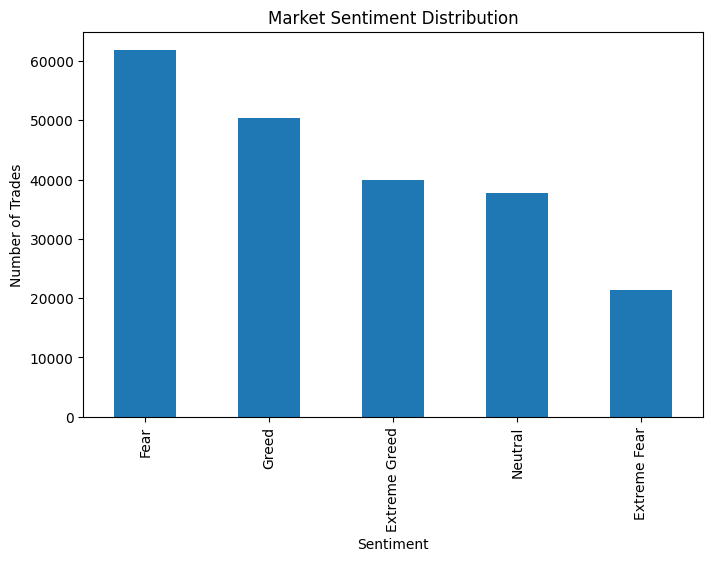

In [57]:
import matplotlib.pyplot as plt

merged["classification"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [58]:
merged.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


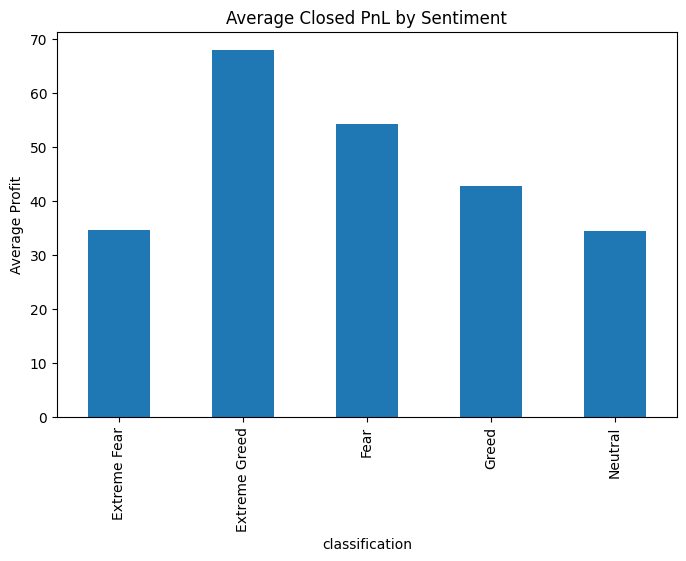

In [59]:
merged.groupby("classification")["Closed PnL"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Closed PnL by Sentiment")
plt.ylabel("Average Profit")
plt.show()

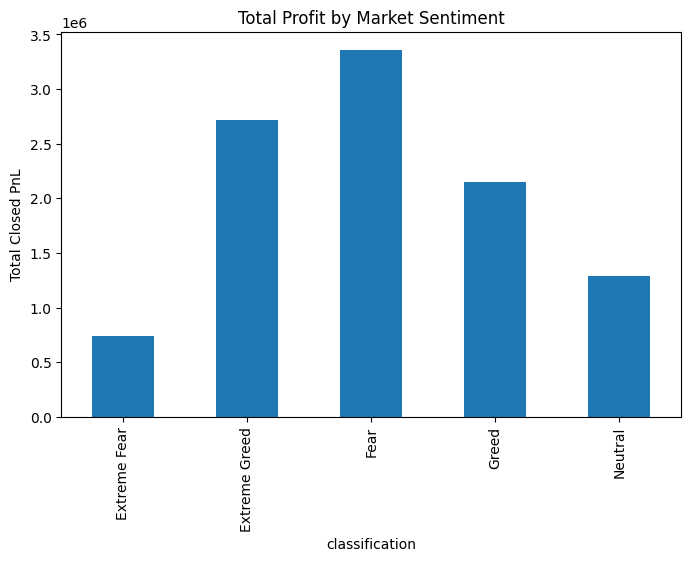

In [60]:
merged.groupby("classification")["Closed PnL"].sum().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Profit by Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.show()

In [61]:
merged["Side"].value_counts()

,count
Side,
SELL,108528
BUY,102696


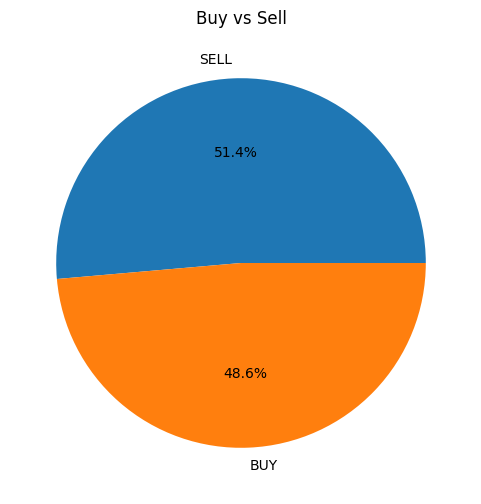

In [62]:
merged["Side"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Buy vs Sell")
plt.ylabel("")
plt.show()

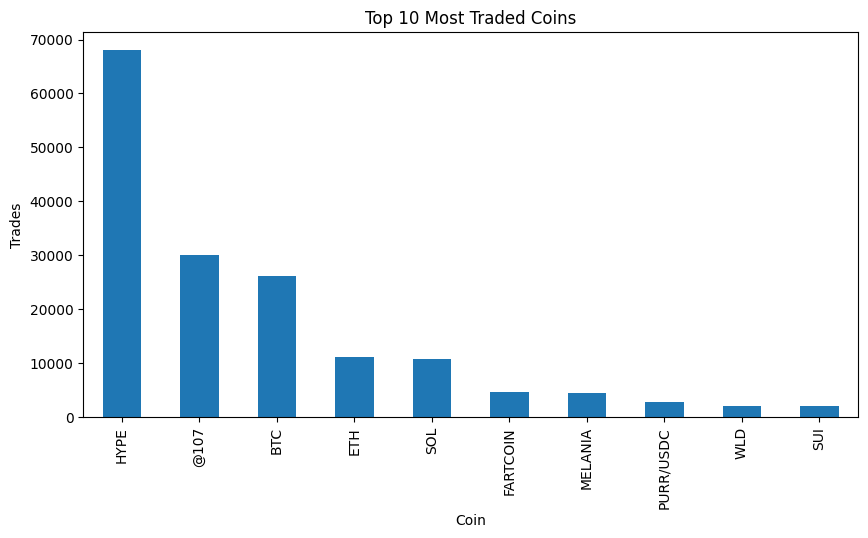

In [63]:
merged["Coin"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Most Traded Coins")
plt.ylabel("Trades")
plt.show()

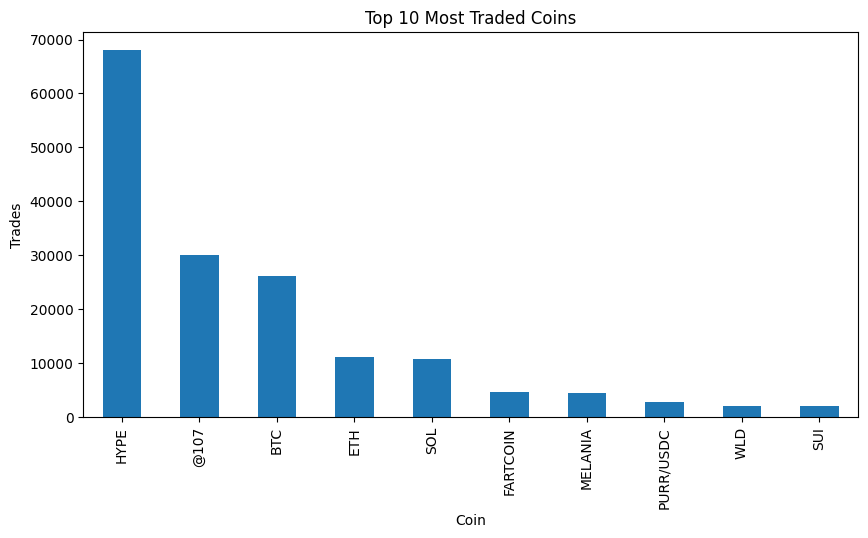

In [64]:
merged["Coin"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Most Traded Coins")
plt.ylabel("Trades")
plt.show()

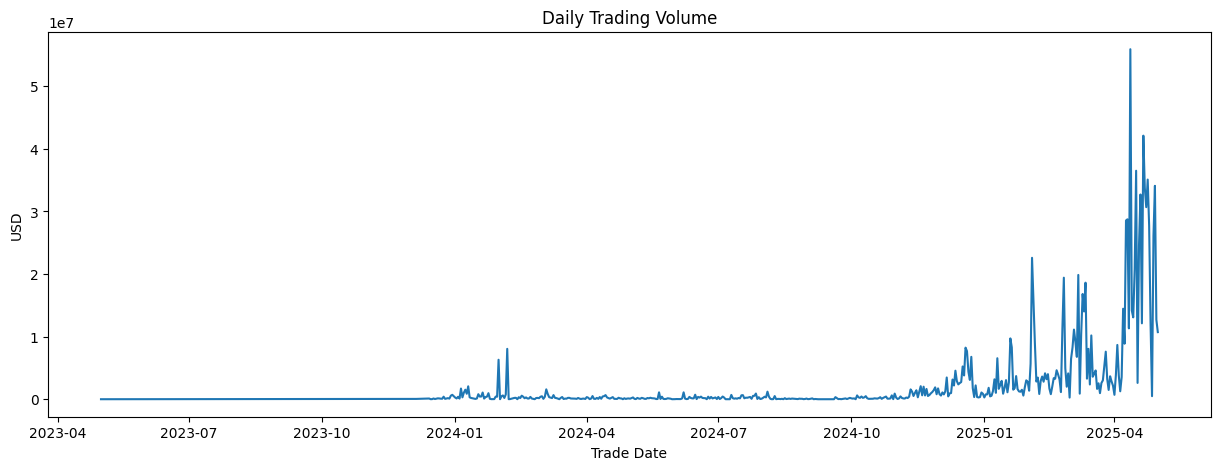

In [65]:
merged.groupby("Trade Date")["Size USD"].sum().plot(
    figsize=(15,5)
)

plt.title("Daily Trading Volume")
plt.ylabel("USD")
plt.show()

In [66]:
numeric = merged.select_dtypes(include=["number"])

numeric.corr()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
Execution Price,1.000000,-0.017185,0.189855,0.017241,-0.006505,0.125850,0.225265,0.001841,0.130714,0.107228,-0.027558
Size Tokens,-0.017185,1.000000,0.013310,0.044660,0.005068,-0.043753,0.006710,-0.003848,-0.040949,-0.050407,0.023080
Size USD,0.189855,0.013310,1.000000,0.007787,0.123589,0.045210,0.745939,0.000245,0.039755,0.035798,-0.029843
Start Position,0.017241,0.044660,0.007787,1.000000,0.004066,-0.082799,0.010559,0.001165,-0.105487,-0.073483,-0.049619
Closed PnL,-0.006505,0.005068,0.123589,0.004066,1.000000,-0.007250,0.084020,0.003466,-0.009745,-0.003404,0.008121
Order ID,0.125850,-0.043753,0.045210,-0.082799,-0.007250,1.000000,0.039303,0.003880,0.929166,0.982959,-0.561758
Fee,0.225265,0.006710,0.745939,0.010559,0.084020,0.039303,1.000000,0.000940,0.036888,0.030180,-0.026877
Trade ID,0.001841,-0.003848,0.000245,0.001165,0.003466,0.003880,0.000940,1.000000,0.002350,0.003081,-0.006574
Timestamp,0.130714,-0.040949,0.039755,-0.105487,-0.009745,0.929166,0.036888,0.002350,1.000000,0.932900,-0.377565
timestamp,0.107228,-0.050407,0.035798,-0.073483,-0.003404,0.982959,0.030180,0.003081,0.932900,1.000000,-0.478040


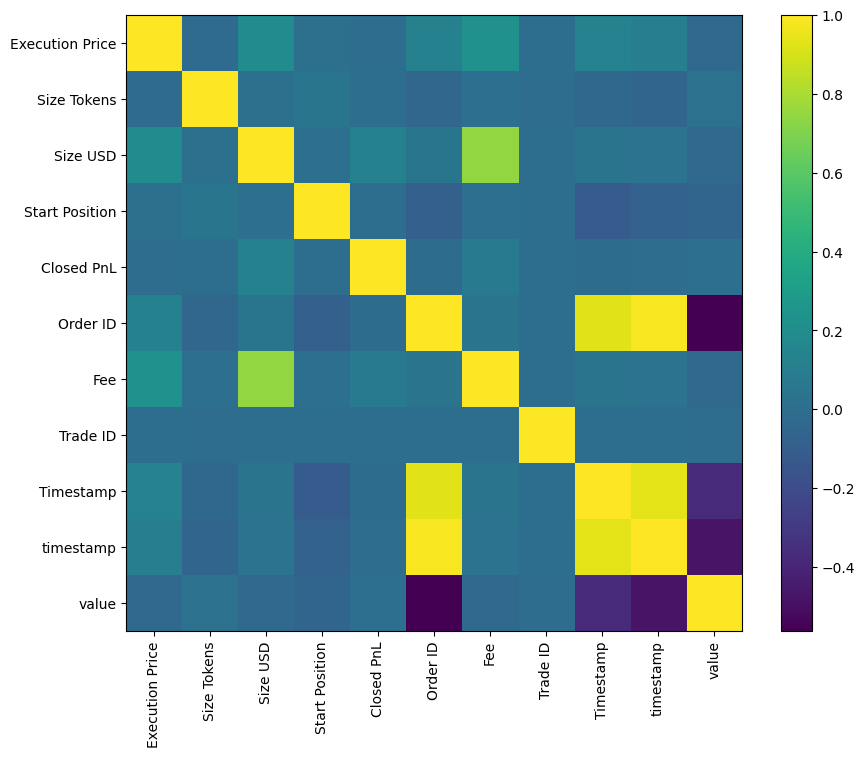

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(numeric.corr())

plt.colorbar()

plt.xticks(range(len(numeric.columns)), numeric.columns, rotation=90)

plt.yticks(range(len(numeric.columns)), numeric.columns)

plt.show()